In [1]:
import sys
import os
sys.path.append("../")
print(os.getcwd())
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import os
from datetime import datetime
from src.model import VAE  

latent_dim = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae_model_path = "../saved_models/vae20250404_203515_vae.pth"
vae = VAE().to(device)  # Match latent_dim to your model

checkpoint = torch.load(vae_model_path, map_location=device)
vae.load_state_dict(checkpoint['model_state_dict'])
vae.eval()  # Set to evaluation mode


/mnt/batch/tasks/shared/LS_root/mounts/clusters/jack-vm/code/Projects/Jack_ForceDeck_Winter_2024/countermovement-jump-analysis/scripts


/tmp/ipykernel_3197/4248034743.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(vae_model_path, map_location=device)


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
  )
  (mean_layer): Linear(in_features=64, out_features=16, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=100, bias=True)
  )
)

In [2]:
data = pd.read_pickle("../data/outlier_removed.pkl")  

In [3]:
import pandas as pd
import torch

data = pd.read_pickle("../data/outlier_removed.pkl")

downsampled_data = data['downsampled_time_series'].values

downsampled_tensor = torch.tensor(downsampled_data.tolist(), dtype=torch.float32).to(device)

def get_latent_vectors(vae, data_tensor):
    vae.eval()  
    with torch.no_grad():  
        encoder_output = vae.encoder(data_tensor)
        return encoder_output.cpu().numpy()

# add the latent vectors to the dataframe
latent_vectors = get_latent_vectors(vae, downsampled_tensor)

data['vae_latent_space'] = list(latent_vectors)

In [4]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,...,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency,reconstruction_loss,outlier,initial_weight,vae_latent_space
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[519.4403179999999, 519.4403179999999, 516.440...",519.440318,"[1.0, 1.0, 0.994224553050578, 0.99422455305057...","[0.9997689723968506, 0.9933004975318909, 0.982...","[2.717329740524292, 1.7964253425598145, 0.9758...",0.309237,0.001501,0,519.440318,"[-0.02615801, -0.013676775, -0.032266647, -0.0..."


In [5]:
len(data["vae_latent_space"][0])

64

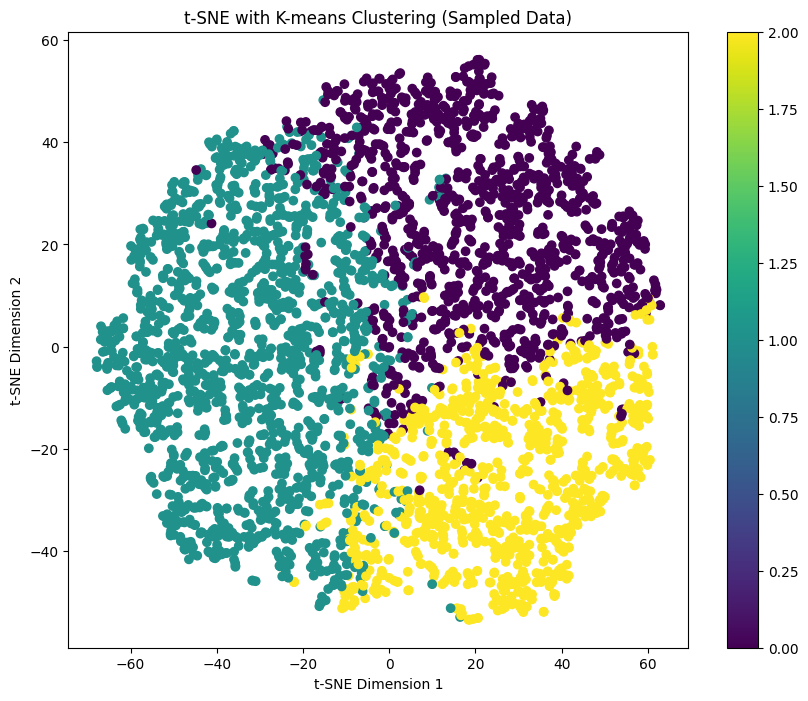

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

sample_size = 4000
sample_indices = np.random.choice(len(latent_vectors), sample_size, replace=False)
latent_sample = latent_vectors[sample_indices]

tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_sample)

kmeans = KMeans(n_clusters=3, random_state=42)  
kmeans.fit(latent_sample)
labels = kmeans.labels_

plt.figure(figsize=(10, 8))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap='viridis')
plt.colorbar()
plt.title("t-SNE with K-means Clustering (Sampled Data)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

# seaborn histplot pf ;atent dims 


In [8]:
def get_latent_stats(vae, data_tensor):
    vae.eval()
    with torch.no_grad():
        mean, logvar = vae.encode(data_tensor)
        std = torch.exp(0.5 * logvar)
        z = vae.reparameterization(mean, std)
    return mean.cpu().numpy(), std.cpu().numpy(), z.cpu().numpy()


In [21]:
means, stds, latents = get_latent_stats(vae, downsampled_tensor)

array([ 0.54720175,  0.38252854, -1.2466729 ,  0.7829142 ,  0.21410547,
        0.69765705, -0.4580966 ,  0.51884353, -2.224819  ,  1.8198706 ,
       -0.7434182 ,  0.31658575, -0.7191308 , -0.88386315, -0.78738636,
        0.8840016 ], dtype=float32)

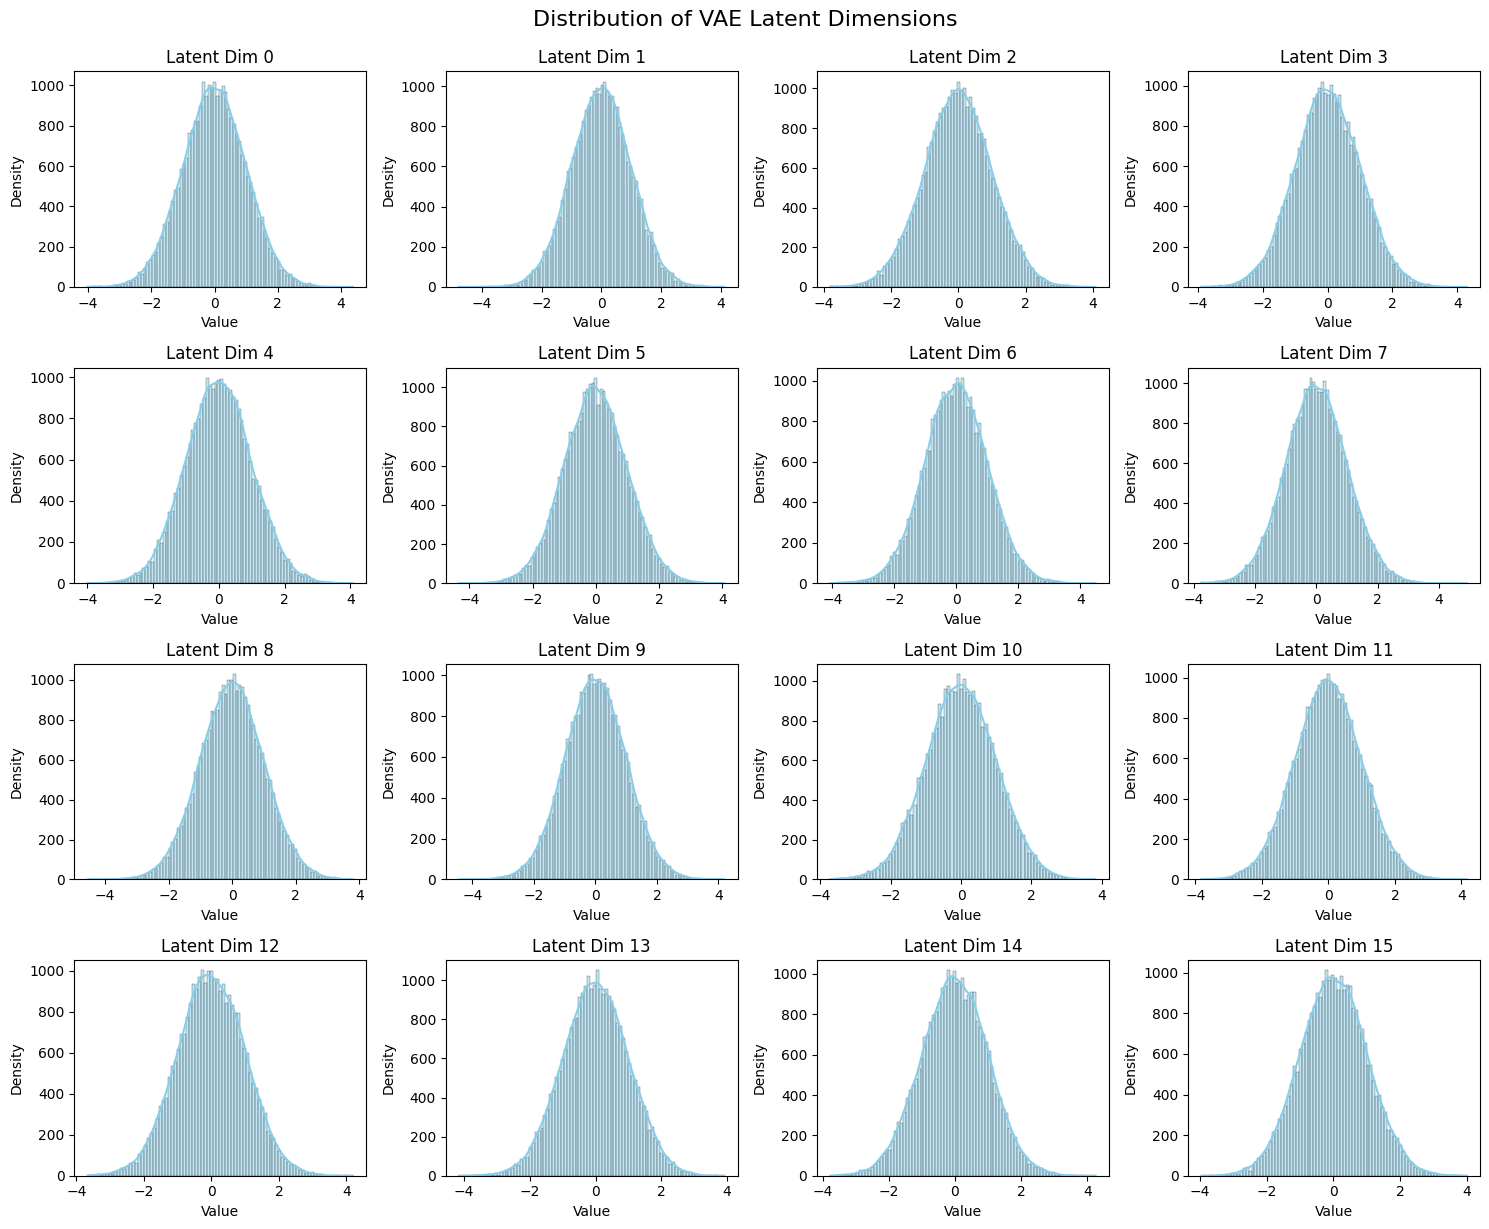

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

latent_dim = latents.shape[1]
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(15, 12)) 
axs = axs.flatten()

for i in range(latent_dim):
    sns.histplot(latents[:, i], kde=True, ax=axs[i], color="skyblue")
    axs[i].set_title(f"Latent Dim {i}")
    axs[i].set_xlabel("Value")
    axs[i].set_ylabel("Density")

plt.tight_layout()
plt.suptitle("Distribution of VAE Latent Dimensions", fontsize=16, y=1.02)
plt.show()


In [23]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,...,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency,reconstruction_loss,outlier,initial_weight,vae_latent_space
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[519.4403179999999, 519.4403179999999, 516.440...",519.440318,"[1.0, 1.0, 0.994224553050578, 0.99422455305057...","[0.9997689723968506, 0.9933004975318909, 0.982...","[2.717329740524292, 1.7964253425598145, 0.9758...",0.309237,0.001501,0,519.440318,"[-0.02615801, -0.013676775, -0.032266647, -0.0..."


# 

In [26]:
latents.T.shape

(16, 28277)

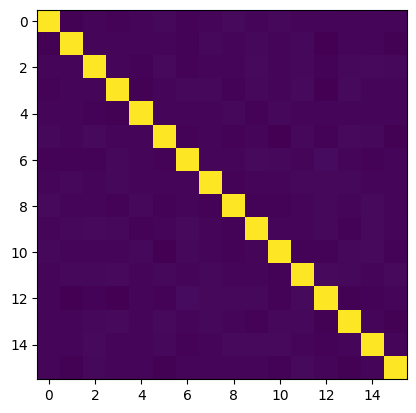

In [29]:
plt.imshow(np.corrcoef(latents.T))

In [60]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,...,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency,reconstruction_loss,outlier,initial_weight,vae_latent_space
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[519.4403179999999, 519.4403179999999, 516.440...",519.440318,"[1.0, 1.0, 0.994224553050578, 0.99422455305057...","[0.9997689723968506, 0.9933004975318909, 0.982...","[2.717329740524292, 1.7964253425598145, 0.9758...",0.309237,0.001501,0,519.440318,"[-0.02615801, -0.013676775, -0.032266647, -0.0..."


In [67]:
import matplotlib.pyplot as plt

def plot_single_reconstruction(vae, data_tensor, index=2):
    vae.eval()
    with torch.no_grad():
        x = data_tensor[index].unsqueeze(0)  # batch dim
        x_hat, _, _ = vae(x)

    original = x.squeeze().cpu().numpy()
    reconstructed = x_hat.squeeze().cpu().numpy()

    plt.figure(figsize=(8, 6))
    plt.plot(original, label="Original", color="blue")
    plt.plot(reconstructed, label="Reconstructed", color="orange", linestyle='--')
    plt.title(f"Original vs Reconstructed - Jump Index: {index}")
    plt.xlabel("Step")
    plt.ylabel("Force")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


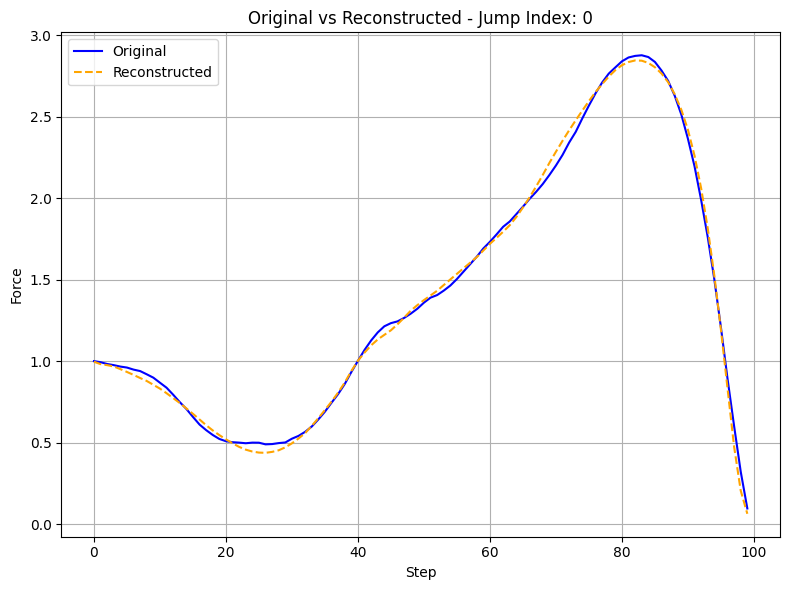

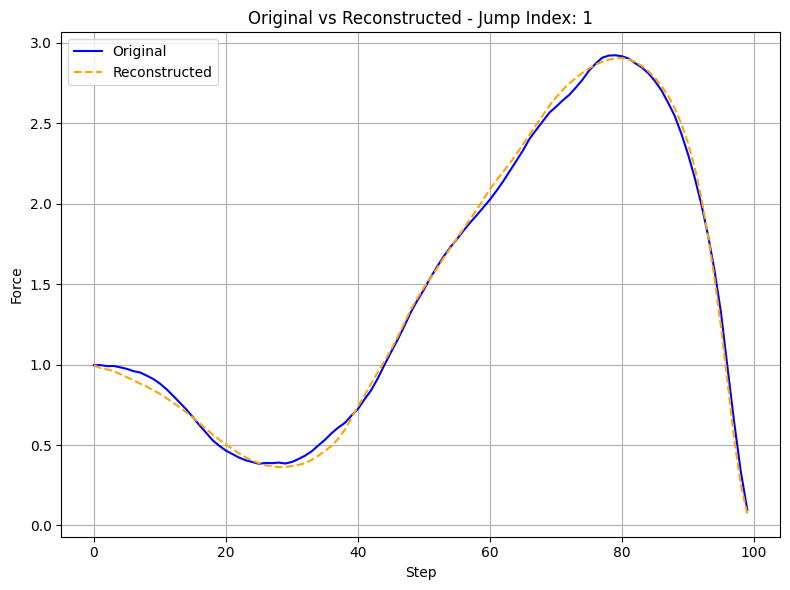

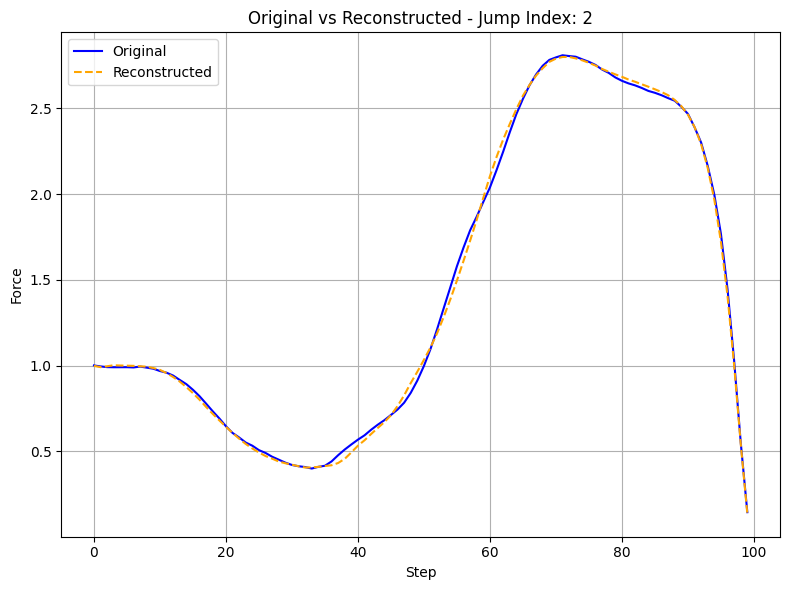

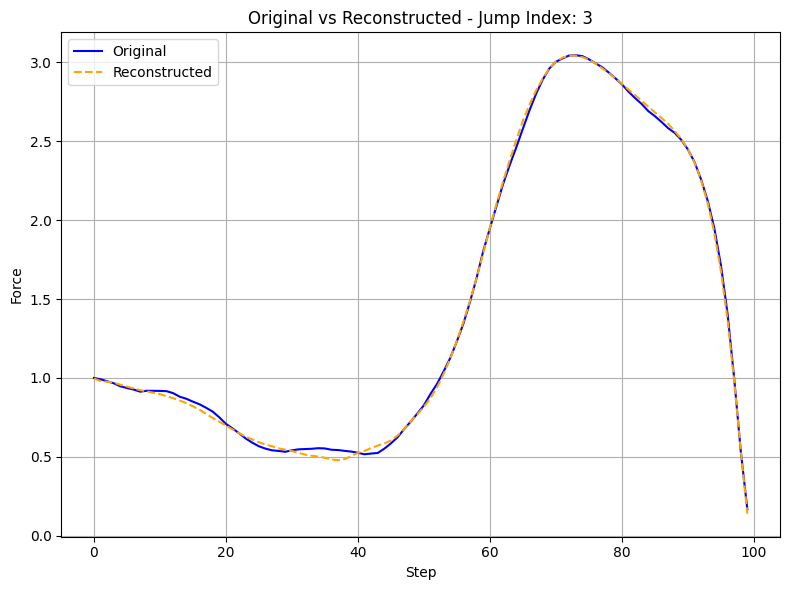

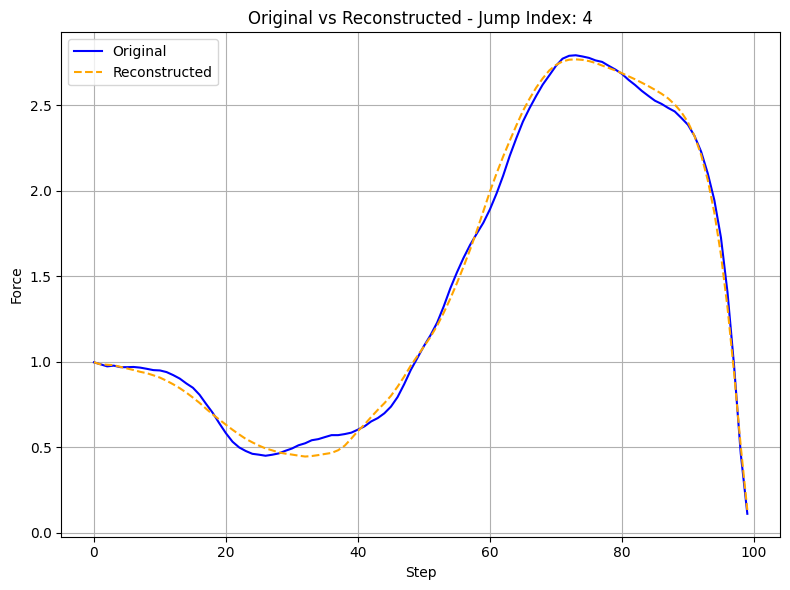

In [68]:
for i in range(5):
    plot_single_reconstruction(vae, downsampled_tensor, index=i)


In [61]:
import torch.nn.functional as F

def compute_reconstruction_errors(vae, data_tensor):
    vae.eval()
    errors = []

    with torch.no_grad():
        for x in data_tensor:
            x = x.unsqueeze(0)  # batch dim
            x_hat, _, _ = vae(x)
            mse = F.mse_loss(x_hat, x).item()
            errors.append(mse)

    return errors


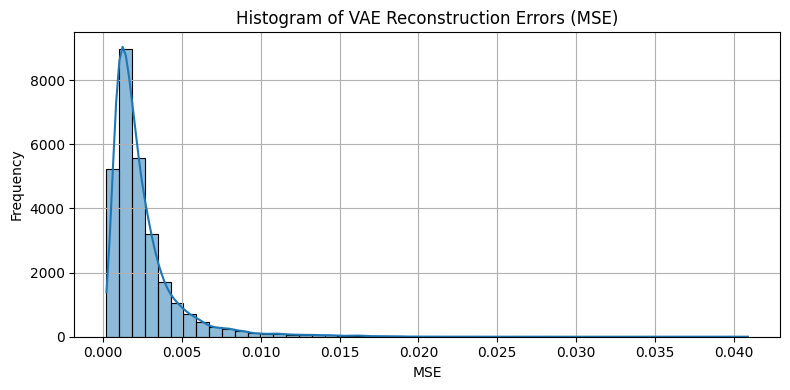

Mean MSE: 0.0025
Median MSE: 0.0018


In [62]:
errors = compute_reconstruction_errors(vae, downsampled_tensor)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(errors, bins=50, kde=True)
plt.title("Histogram of VAE Reconstruction Errors (MSE)")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Mean MSE: {np.mean(errors):.4f}")
print(f"Median MSE: {np.median(errors):.4f}")


In [ ]:
# impact of latent dim on jump height
# t-sne plot 
# 